# Imports + Helper Functions

In [1]:
from equi7grid_lite import Equi7Grid
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
# Set font sizes for various components
plt.rcParams.update({
    'font.size': 14,           # Global font size
    'axes.titlesize': 18,      # Title font size
    'axes.labelsize': 16,      # X and Y label font size
    'xtick.labelsize': 14,     # X tick label font size
    'ytick.labelsize': 14,     # Y tick label font size
})

In [3]:
def calculate_area(gdf):
    """Calculate area in square meters and square kilometers for a GeoDataFrame."""
    # Set the coordinate reference system (CRS) for the GeoDataFrame to WGS84
    gdf.crs = 'EPSG:4326'
    
    # Calculate the area in degrees (not used for final calculation, but keeping it here if needed for other purposes)
    #gdf['area_degrees'] = gdf.geometry.area
    
    # Define the target projection system (e.g., UTM Zone 18N)
    target_crs = 'EPSG:32618'
    
    # Reproject the GeoDataFrame to the target projection system
    gdf_projected = gdf.to_crs(target_crs)
    
    # Calculate the area in square meters
    gdf_projected['area_meters'] = gdf_projected.geometry.area
    
    # Convert square meters to square kilometers
    gdf['areakm2'] = gdf_projected['area_meters'] / 1e6
    
    
    # Return the GeoDataFrame with the new area columns
    return gdf

# Equi7Grid

In [119]:
grid_system = Equi7Grid(min_grid_size=512) # 1370 gridsize
grid_system

Equi7Grid(min_grid_size=512)
----------------
levels: 0, 1, ... , 10, 11
zones: AN, NA, OC, SA, AF, EU, AS
min_grid_size: 512 meters
max_grid_size: 2097152 meters

,zone,level,land,geometry
0,NA,Z3,True,"POLYGON ((11591680 1728512, 11591680 1732608, ..."
1,NA,Z3,True,"POLYGON ((11591680 1732608, 11591680 1736704, ..."
2,NA,Z3,True,"POLYGON ((11595776 1724416, 11595776 1728512, ..."
3,NA,Z3,True,"POLYGON ((11595776 1728512, 11595776 1732608, ..."
4,NA,Z3,True,"POLYGON ((11595776 1732608, 11595776 1736704, ..."
...,...,...,...,...
649,NA,Z3,True,"POLYGON ((11771904 1781760, 11771904 1785856, ..."
650,NA,Z3,True,"POLYGON ((11771904 1785856, 11771904 1789952, ..."
651,NA,Z3,False,"POLYGON ((11771904 1789952, 11771904 1794048, ..."
652,NA,Z3,True,"POLYGON ((11776000 1781760, 11776000 1785856, ..."


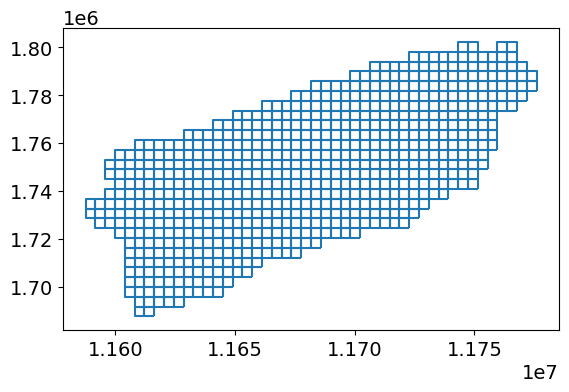

In [120]:
# Define a POLYGON geometry
usa_filepath = '/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/data/S_USA.AdministrativeRegion/S_USA.AdministrativeRegion.shp'
usa = gpd.read_file(usa_filepath)
country = usa[usa.REGION == "08"]
region = country.explode()[1:2]

# Create a grid of Equi7Grid tiles that cover the bounding box of the POLYGON geometry
grid = grid_system.create_grid(
    level=3,
    zone="NA",
    mask=region # Only include tiles that intersect the polygon   
)
grid.boundary.plot()
grid


In [121]:
grid_epsg4326 = grid.to_crs(epsg=4326)
grid_epsg4326 = calculate_area(grid_epsg4326)
print(len(grid_epsg4326))
size = grid_epsg4326[0:1]['areakm2'][0]
print(f'Size of Grid: {size} km²')
grid_epsg4326[0:10]

654
Size of Grid: 15.617286168509287 km²


,zone,level,land,geometry,areakm2
0,NA,Z3,True,"POLYGON ((-67.27445 18.33245, -67.26425 18.366...",15.617286
1,NA,Z3,True,"POLYGON ((-67.26425 18.36649, -67.25404 18.400...",15.619576
2,NA,Z3,True,"POLYGON ((-67.24985 18.28569, -67.23966 18.319...",15.615549
3,NA,Z3,True,"POLYGON ((-67.23966 18.31972, -67.22945 18.353...",15.617843
4,NA,Z3,True,"POLYGON ((-67.22945 18.35375, -67.21923 18.387...",15.620136
5,NA,Z3,True,"POLYGON ((-67.21508 18.27295, -67.20487 18.306...",15.616111
6,NA,Z3,True,"POLYGON ((-67.20487 18.30698, -67.19466 18.341...",15.618408
7,NA,Z3,True,"POLYGON ((-67.19466 18.341, -67.18443 18.37502...",15.620704
8,NA,Z3,True,"POLYGON ((-67.18443 18.37502, -67.17419 18.409...",15.622999
9,NA,Z3,True,"POLYGON ((-67.16394 18.44305, -67.15368 18.477...",15.627586


In [52]:
# Define a POLYGON geometry
path = '/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/convex_hulls_refdm.shp'
conves = gpd.read_file(path)
conves

,USDA_IDX,geometry
0,bark_beetle_2017_0,"POLYGON ((-86.08953 32.13766, -86.09646 32.138..."
1,bark_beetle_2017_1,"POLYGON ((-86.01467 32.00506, -86.01698 32.005..."
2,bark_beetle_2017_10,"POLYGON ((-86.99129 32.65939, -86.99226 32.659..."
3,bark_beetle_2017_100,"POLYGON ((-87.11667 32.8805, -87.11841 32.8812..."
4,bark_beetle_2017_1000,"POLYGON ((-88.94792 34.00561, -88.95005 34.006..."
...,...,...
7908,wind_2020_9299,"POLYGON ((-88.52876 36.07517, -88.5325 36.0757..."
7909,wind_2020_9300,"POLYGON ((-85.8543 36.14892, -85.8543 36.14912..."
7910,wind_2020_9302,"POLYGON ((-85.44875 36.10135, -85.44973 36.101..."
7911,wind_2020_9304,"POLYGON ((-84.99426 36.12806, -85.00986 36.130..."


<Axes: >

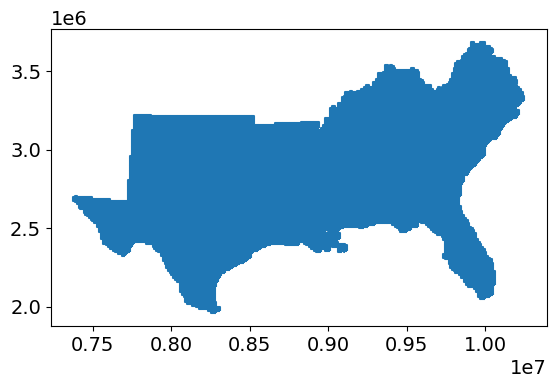

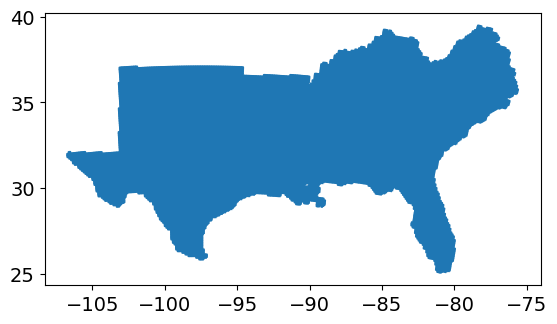

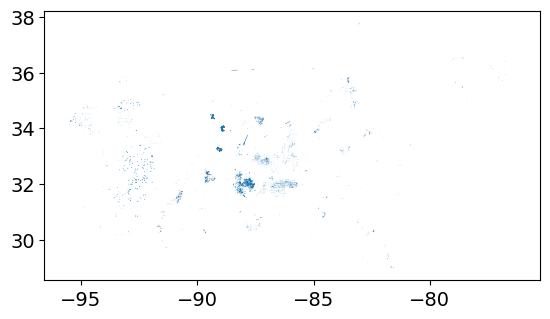

In [109]:
grid.boundary.plot()
grid_epsg4326.boundary.plot()
conves.plot()

In [117]:
intersected_gdf = gpd.sjoin(grid_epsg4326, conves, how='inner', predicate='intersects')
intersected_gdf = intersected_gdf.reset_index()
intersected_gdf = intersected_gdf.drop(columns=['index_right','USDA_IDX','areakm2','level','land','zone'])
intersected_gdf = intersected_gdf.drop_duplicates()
intersected_gdf = intersected_gdf.reset_index()
intersected_gdf = intersected_gdf.drop(columns=['level_0','index'])
intersected_gdf

,geometry
0,"POLYGON ((-95.51701 34.30867, -95.51433 34.407..."
1,"POLYGON ((-95.5035 34.80247, -95.50077 34.9012..."
2,"POLYGON ((-95.4055 34.1086, -95.40268 34.20736..."
3,"POLYGON ((-95.40268 34.20736, -95.39985 34.306..."
4,"POLYGON ((-95.39702 34.40488, -95.39417 34.503..."
...,...
1240,"POLYGON ((-76.70148 35.8095, -76.67259 35.9039..."
1241,"POLYGON ((-76.67259 35.90397, -76.64359 35.998..."
1242,"POLYGON ((-76.49829 36.06679, -76.46894 36.161..."
1243,"POLYGON ((-76.43947 36.25553, -76.4099 36.3498..."


1245


<Axes: >

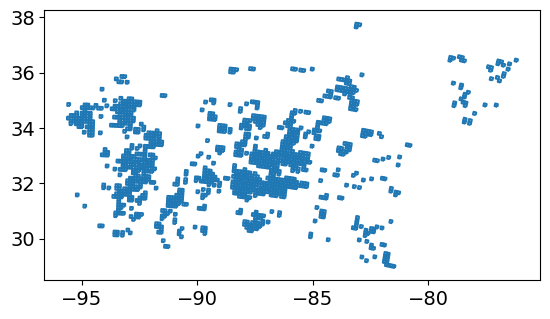

In [110]:
print(len(intersected_gdf))
intersected_gdf.boundary.plot()

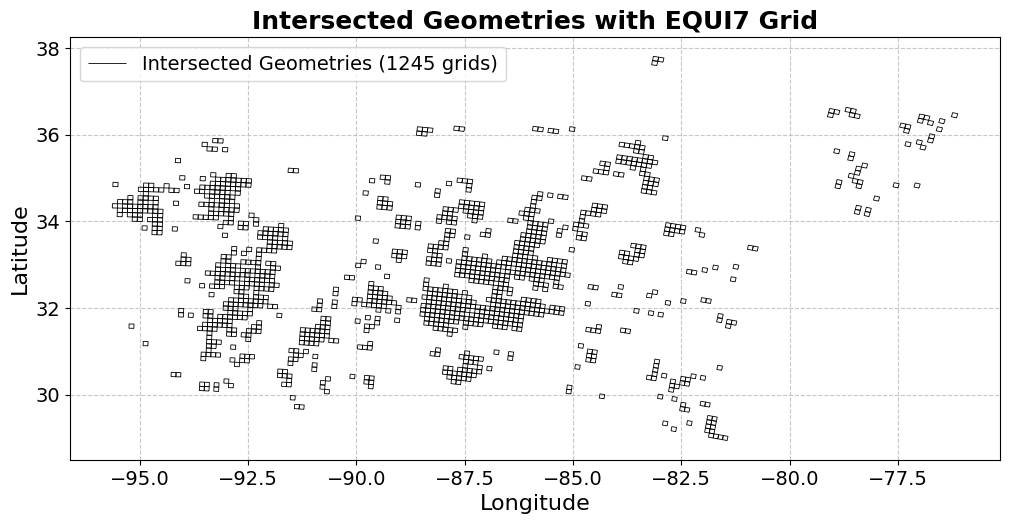

In [116]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load your GeoDataFrames
# intersected_gdf = gpd.read_file('path_to_your_intersected_gdf.shp')
# country = gpd.read_file('path_to_your_country_shapefile.shp')

# Example data for region 8
region = country.explode()[0:1]  # Adjust this line as needed to select region 8

# Plot the boundary of the intersected geometries and region 8 with enhancements
fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed

# Plot the boundaries of intersected_gdf
intersected_gdf.boundary.plot(ax=ax, color='black', linewidth=0.6, linestyle='-', zorder=2)

# Plot the boundary of region 8
region.boundary.plot(ax=ax, color='red', linewidth=0.5, linestyle='--', zorder=3)

# Customize the plot appearance
ax.set_title('Intersected Geometries with EQUI7 Grid and Region 8 Boundary', fontsize=18, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

# Set the aspect ratio of the plot to be equal
ax.set_aspect('equal')

# Optional: Add a legend if needed
ax.legend([f'Intersected Geometries ({len(intersected_gdf)} grids)', 'Region 8 Boundary'], loc='upper left', fontsize=14)

plt.show()


In [118]:
grid.to_file("/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/grids/grid.shp")
grid_epsg4326.to_file("/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/grids/grid_epsg4326.shp")
intersected_gdf.to_file("/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/grids/intersected_grid_espg.shp")